In [15]:
import pandas as pd
import numpy as np
import os


os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())

C:\Users\cuent\En-Peu\notebooks


In [16]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   AC       64345 non-null  float64
 5   CIB      64345 non-null  float64
 6   CICCB    64345 non-null  float64
 7   DBB      64345 non-null  float64
 8   DOB      64345 non-null  float64
 9   P        64345 non-null  float64
 10  CUS_1    64345 non-null  float64
 11  CUS_2    64345 non-null  float64
 12  CUS_3    64345 non-null  float64
 13  CUS_4    64345 non-null  float64
 14  CUS_5    64345 non-null  float64
 15  OC_1     64345 non-null  float64
 16  OC_2     64345 non-null  float64
 17  OC_3     64345 non-null  float64
 18  OC_4     64345 non-null  float64
dtypes: float64(19)
memory usage: 9.3 MB
None


In [14]:
# 1. Autenticación e inicio de Earth Engine
import ee
ee.Authenticate()
ee.Initialize()

ModuleNotFoundError: No module named 'ee'

In [ ]:
# 3. Función para obtener embeddings AlphaEarth 2024
def fetch_embedding_2024(lon, lat):
    try:
        pt = ee.Geometry.Point([lon, lat])
        collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
                        .filterDate("2024-01-01", "2025-01-01") \
                        .filterBounds(pt)
        
        # Si no hay imágenes, saltar
        if collection.size().getInfo() == 0:
            return [None] * 64
        
        img = collection.first()
        band_names = [f"A{str(i).zfill(2)}" for i in range(64)]
        vals = img.select(band_names).reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=pt,
            scale=10
        ).getInfo()
        
        return [vals.get(b) for b in band_names]
    
    except Exception as e:
        print(f"Error en punto ({lon}, {lat}): {e}")
        return [None] * 64


In [ ]:
# 4. Extraer embeddings para todos los puntos
embeddings_list = []
for idx, row in data.iterrows():
    emb = fetch_embedding_2024(row['POINT_X'], row['POINT_Y'])
    embeddings_list.append(emb)

In [ ]:
# 5. Unir embeddings al DataFrame
emb_df = pd.DataFrame(embeddings_list, columns=[f"emb_{i}" for i in range(64)])
df_with_emb = pd.concat([data, emb_df], axis=1)

# 6. Guardar
nombre_archivo_salida = "data_con_embeddings.csv"
df_with_emb.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False)

print("CSV con embeddings de 2024 guardado como data_con_embeddings.csv")

In [17]:
# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', "data_con_embeddings.csv")

# Cargar el archivo CSV
data = pd.read_csv(file_path)

In [18]:
# 2. Contar valores faltantes por columna
print("Valores faltantes por columna:")
print(data.isnull().sum())

Valores faltantes por columna:
POINT_X    0
POINT_Y    0
PLA        0
A          0
AC         0
          ..
emb_59     0
emb_60     0
emb_61     0
emb_62     0
emb_63     0
Length: 85, dtype: int64


Vemos si hace falta normalizar los embeddings

              emb_0         emb_1         emb_2         emb_3         emb_4  \
count  64345.000000  64345.000000  64345.000000  64345.000000  64345.000000   
mean       0.063687     -0.190195      0.145206      0.011442     -0.035059   
std        0.070219      0.061768      0.069462      0.071557      0.042655   
min       -0.135886     -0.413626     -0.098424     -0.179377     -0.214133   
25%        0.015748     -0.228897      0.093564     -0.044844     -0.062991   
50%        0.055363     -0.186082      0.147697      0.015748     -0.035433   
75%        0.108512     -0.141730      0.192910      0.062991     -0.008858   
max        0.259900     -0.022207      0.374256      0.221453      0.108512   

              emb_5         emb_6         emb_7         emb_8         emb_9  \
count  64345.000000  64345.000000  64345.000000  64345.000000  64345.000000   
mean      -0.015525      0.144107      0.008313     -0.095929     -0.025307   
std        0.112773      0.071856      0.072904    

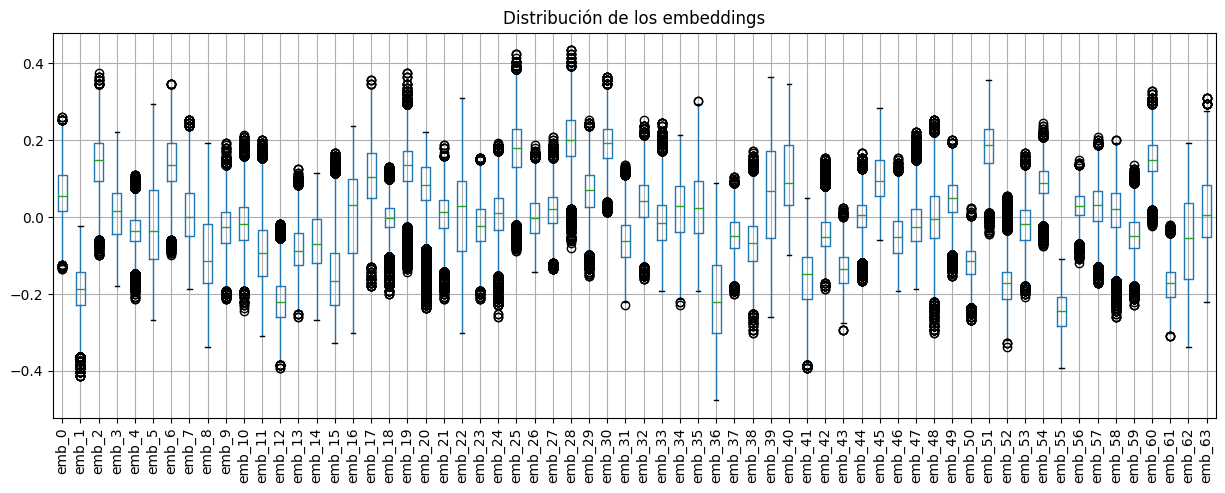

In [19]:
import matplotlib.pyplot as plt

# Seleccionar solo columnas de embeddings
emb_cols = [col for col in data.columns if col.startswith('emb_')]
emb_data = data[emb_cols]

# Estadísticas descriptivas
print(emb_data.describe())

# Boxplots para ver la distribución por embedding
plt.figure(figsize=(15, 5))
emb_data.boxplot(rot=90)
plt.title("Distribución de los embeddings")
plt.savefig(os.path.join(parent_directory, 'images','boxplot_embeddings.png'), bbox_inches='tight', dpi=300)
plt.show()

Los datos se encuentran entre -0.5 y 0.5 aproximadamente, por lo que no haría falta normalizar. Ahora veremos si hay correlaciones grandes entre los embeddings y nuestras variables originales.

In [20]:
import seaborn as sns

# Seleccionar variables originales + embeddings
num_cols = [c for c in data.columns if c not in emb_cols and data[c].dtype != 'object']
corr_matrix = data[num_cols + emb_cols].corr()

# Filtrar solo correlaciones de tus variables originales con embeddings
orig_vs_emb_corr = corr_matrix.loc[num_cols, emb_cols]

print(corr_matrix)

print(corr_matrix.isnull().sum())

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Heatmap correlación
plt.figure(figsize=(15, 6))
sns.heatmap(orig_vs_emb_corr, cmap='coolwarm', center=0)
plt.title("Correlación entre variables originales y embeddings")
plt.savefig(os.path.join(parent_directory, 'images','corr_embeddings.png'), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Ver correlaciones muy altas (en valor absoluto)
high_corrs = orig_vs_emb_corr[(orig_vs_emb_corr.abs() > 0.8)]
print("Correlaciones fuertes encontradas:")
print(high_corrs.dropna(how='all', axis=0).dropna(how='all', axis=1))

No hay ninguna correlación mayor al 80%. 
Ahora hay que preparar los datos para utilizarlos en el modelo.

In [21]:
from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
coordinates = data[['POINT_X', 'POINT_Y']].copy()
lonlat = data[['lon', 'lat']].copy()
X = data.drop(columns=['PLA', 'POINT_X','POINT_Y', 'lon', 'lat'])
# y será la columna 'PLA'
y = data['PLA']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())


Forma de X_train (características de entrenamiento): (51476, 80)
Forma de y_train (etiquetas de entrenamiento): (51476,)
Forma de X_test (características de prueba): (12869, 80)
Forma de y_test (etiquetas de prueba): (12869,)

Primeras filas de X_train:
              A        AC       CIB     CICCB       DBB       DOB         P  \
48196  0.634369  0.324476  0.101781  0.291697  0.484058  0.605235  0.036417   
31410  0.721612  0.027246  0.778726  0.541413  0.138255  0.208782  0.020722   
23835  0.534206  1.000000  0.043877  0.236189  0.285055  0.631355  0.000000   
53962  0.584288  0.324476  0.401558  0.193533  0.679098  0.738164  0.058812   
45212  0.805616  1.000000  0.816241  0.443402  0.213456  0.300115  0.032442   

       CUS_1  CUS_2  CUS_3  ...    emb_54    emb_55    emb_56    emb_57  \
48196    0.0    0.0    0.0  ...  0.103406 -0.179377  0.038447  0.059116   
31410    0.0    1.0    0.0  ...  0.119093 -0.244152  0.032541  0.044844   
23835    1.0    0.0    0.0  ...  0.119093 -0.

In [22]:
import xgboost as xgb # Using XGBoost for GBM
from sklearn.model_selection import train_test_split, GridSearchCV # For cross-validation and hyperparameter tuning
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # For evaluation metrics
import joblib # To save/load models and for parallel processing

# --- 1. Paralelización (Gestionado por scikit-learn con 'n_jobs') ---
# En Python con scikit-learn, la paralelización se maneja con el parámetro `n_jobs`.
# n_jobs = -1 significa usar todos los núcleos disponibles.
# n_jobs = -2 significa usar todos los núcleos excepto 1.
n_cores = joblib.cpu_count() - 1
print(f"\nDetectados {joblib.cpu_count()} núcleos, usando {n_cores} para paralelización.")


# --- 2. Control de validación cruzada (GridSearchCV) ---
# 'trainControl' de caret se traduce a GridSearchCV de scikit-learn
# metric = "RMSE" en R es 'neg_root_mean_squared_error' en scikit-learn (para minimizar)
# Ojo: GridSearchCV siempre intenta MAXIMIZAR la métrica, por eso es 'negativo RMSE'.
scoring_metric = 'neg_root_mean_squared_error' # Minimizar RMSE -> Maximizar -RMSE



Detectados 20 núcleos, usando 19 para paralelización.


In [23]:
# --- 3. GBM (Gradient Boosting Machine) con XGBoost ---

# Definir la cuadrícula de hiperparámetros para XGBoost

grid_gbm = {
    'max_depth': [1, 3],
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.1],
    'min_child_weight': [10] # Un valor similar a n.minobsinnode
}

# Inicializar el modelo base (XGBoost Regressor para problemas de regresión)
# objective='reg:squarederror' es el objetivo estándar para regresión con RMSE
model_gbm_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Configurar GridSearchCV para la búsqueda de hiperparámetros y CV
modelo_gbm = GridSearchCV(
    estimator=model_gbm_base,
    param_grid=grid_gbm,
    cv=10, # 'number = 10' en trainControl
    scoring=scoring_metric,
    verbose=1, # Muestra el progreso
    n_jobs=n_cores, # Paralelización: usar todos los núcleos menos 1
    return_train_score=False # No necesitamos scores de entrenamiento para este caso
)

# Entrenar el modelo
print("\nIniciando entrenamiento del modelo GBM con GridSearchCV...")
modelo_gbm.fit(X_train, y_train)

# Mejores hiperparámetros
print("\nMejores hiperparámetros GBM:")
print(modelo_gbm.best_params_)

# Mejor score (RMSE negativo)
print(f"Mejor score de validación (neg_root_mean_squared_error): {modelo_gbm.best_score_:.4f}")
print(f"Mejor RMSE de validación: {-modelo_gbm.best_score_:.4f}")

# Guardar el modelo entrenado
# En Python, se usa 'joblib' o 'pickle' para guardar modelos. Joblib es preferido para modelos de scikit-learn.
joblib.dump(modelo_gbm.best_estimator_, os.path.join(parent_directory, 'models', 'modelo_gbm_embed.pkl'))
print("\nModelo GBM guardado como 'modelo_gbm.pkl' en '{os.path.join(parent_directory,'models','modelo_gbm_embed.pkl')}'")



Iniciando entrenamiento del modelo GBM con GridSearchCV...
Fitting 10 folds for each of 8 candidates, totalling 80 fits

Mejores hiperparámetros GBM:
{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 500}
Mejor score de validación (neg_root_mean_squared_error): -0.0238
Mejor RMSE de validación: 0.0238

Modelo GBM guardado como 'modelo_gbm.pkl' en '{os.path.join(parent_directory,'models','modelo_gbm_embed.pkl')}'


In [24]:
# --- 4. Realizar Predicciones y Evaluar ---
# Cargar el modelo sería así
# modelo_gbm = joblib.load('modelo_gbm.pkl')

# Realizar predicciones sobre el conjunto de prueba
predicciones_gbm = modelo_gbm.predict(X_test) # Usamos el modelo optimizado de GridSearchCV

### Desnormalización
 
# Cargar el scaler guardado en el notebook anterior
scaler_path = os.path.join(parent_directory, 'data','min_max_scaler.pkl')
loaded_scaler = joblib.load(scaler_path)

min_pla = loaded_scaler.data_min_[0]
range_pla = loaded_scaler.data_range_[0]

# Desnormalizar manualmente con los min/max específicos de PLA
predicciones_gbm_desnormalized = predicciones_gbm * range_pla + min_pla
y_test_desnormalized = y_test * range_pla + min_pla



# Evaluar métricas ya desnormalizadas

rmse_desnormalized_gbm = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_gbm_desnormalized))
mae_desnormalized_gbm = mean_absolute_error(y_test_desnormalized, predicciones_gbm_desnormalized)
r2_desnormalized_gbm = r2_score(y_test_desnormalized, predicciones_gbm_desnormalized)

print(f"\n--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_gbm:.4f}")
print(f"MAE: {mae_desnormalized_gbm:.4f}")
print(f"R-squared: {r2_desnormalized_gbm:.4f}")


--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.2185
MAE: 0.1452
R-squared: 0.8872


C:\Users\cuent\anaconda3\envs\flood\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Se ve una ligera mejora con respecto al modelo sin embeddings.

In [25]:
# --- 5. Importancia de Variables (similar a varImp en R) ---
# La importancia de variables está disponible en el mejor estimador del modelo GBM
print("\nImportancia de variables GBM:")
# Las columnas de X_train deben ser un índice para el resultado de importancia
feature_importances_gbm = pd.Series(modelo_gbm.best_estimator_.feature_importances_, index=X_train.columns)
print(feature_importances_gbm.sort_values(ascending=False))


Importancia de variables GBM:
emb_22    0.109834
CIB       0.082702
OC_3      0.060897
emb_55    0.050171
DOB       0.040728
            ...   
emb_23    0.001493
OC_4      0.000000
CUS_3     0.000000
CUS_2     0.000000
CUS_1     0.000000
Length: 80, dtype: float32


In [26]:
#################################
### 2. Random Forest
##################################


from sklearn.ensemble import RandomForestRegressor # For Random Forest




# Definir la cuadrícula de hiperparámetros para RandomForestRegressor
# Equivalencias:
# mtry (R, randomForest package) -> max_features (scikit-learn)
# max_features es el número de características a considerar para el mejor split
# ntree (R) -> n_estimators (scikit-learn)
grid_rf = {
    'n_estimators': [500,1000], # Corresponde a 'ntree = 500' en R (si no lo pusiste en tuneGrid)
                            # Para tunearlo, poner c(100, 500)
    'random_state': [42], # Para reproducibilidad del modelo RF
    'max_features': [5, 10, 20, 40, 'sqrt', 'log2'], # Corresponde a 'mtry'
    'min_samples_leaf': [1,2,5],
    'min_samples_split': [2,5,10]

}

# Inicializar el modelo base (RandomForestRegressor para regresión)
model_rf_base = RandomForestRegressor()#

# Configurar GridSearchCV para la búsqueda de hiperparámetros y CV
modelo_rf_grid = GridSearchCV(
    estimator=model_rf_base,
    param_grid=grid_rf,
    cv=10, # 'number = 10' en trainControl
    scoring=scoring_metric,
    verbose=2, # Muestra el progreso
    n_jobs=n_cores, # Paralelización: usar todos los núcleos menos 1
    return_train_score=False
)

 #Entrenar el modelo
print("\nIniciando entrenamiento del modelo Random Forest con GridSearchCV...")
modelo_rf_grid.fit(X_train, y_train)

# Mejores hiperparámetros
print("\nMejores hiperparámetros Random Forest:")
print(modelo_rf_grid.best_params_)

# Mejor score (RMSE negativo)
print(f"Mejor score de validación (neg_root_mean_squared_error): {modelo_rf_grid.best_score_:.4f}")
print(f"Mejor RMSE de validación: {-modelo_rf_grid.best_score_:.4f}")


Iniciando entrenamiento del modelo Random Forest con GridSearchCV...
Fitting 10 folds for each of 108 candidates, totalling 1080 fits

Mejores hiperparámetros Random Forest:
{'max_features': 40, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000, 'random_state': 42}
Mejor score de validación (neg_root_mean_squared_error): -0.0139
Mejor RMSE de validación: 0.0139


In [28]:
# --- 5. Importancia de Variables (similar a varImp en R) ---
# La importancia de variables está disponible en el mejor estimador del modelo RF
print("\nImportancia de variables RF:")
# Asegúrate de que las columnas de X_train sean un índice para el resultado de importancia
feature_importances_rf = pd.Series(modelo_rf_grid.best_estimator_.feature_importances_, index=X_train.columns)
print(feature_importances_rf.sort_values(ascending=False))


Importancia de variables RF:
CIB      0.204521
DOB      0.109749
DBB      0.104453
A        0.100685
CICCB    0.079834
           ...   
CUS_5    0.000294
CUS_3    0.000226
OC_2     0.000222
OC_1     0.000123
CUS_2    0.000076
Length: 80, dtype: float64


In [27]:
# --- 4. Realizar Predicciones y Evaluar ---
# Realizar predicciones sobre el conjunto de prueba (en la escala normalizada)

# Cargar el modelo sería así
# modelo_rf_grid = joblib.load('modelo_rf.pkl')


predicciones_rf = modelo_rf_grid.predict(X_test)

# --- DESNORMALIZAR LAS PREDICCIONES Y LOS VALORES REALES DE PRUEBA ---

# Desnormalizar manualmente con los min/max específicos de PLA
predicciones_rf_desnormalized = predicciones_rf * range_pla + min_pla
y_test_desnormalized = y_test * range_pla + min_pla


# --- Calcular métricas con valores desnormalizados ---
rmse_desnormalized_rf = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_rf_desnormalized))
mae_desnormalized_rf = mean_absolute_error(y_test_desnormalized, predicciones_rf_desnormalized)
r2_desnormalized_rf = r2_score(y_test_desnormalized, predicciones_rf_desnormalized)

print(f"\n--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_rf:.4f}")
print(f"MAE: {mae_desnormalized_rf:.4f}")
print(f"R-squared: {r2_desnormalized_rf:.4f}")





--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.1219
MAE: 0.0480
R-squared: 0.9649
